Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.stats as stats
import json
import pandas as pd
import os

# custom define colours
blue = '#00668d'
light_blue = '#0099CE'
green = '#73a237'
light_green = '#9cc045'
gray = '#686867'
light_gray = '#b2b2b2'
yellow = '#e0b02e'
light_yellow = '#ffce44'
red = '#a44a3f'
purple = '#49111c'
pink = '#d88c9a'

# change the font to LM Roman 12
import matplotlib.font_manager as fm
fm.fontManager.addfont('C://Users//hoel_m0//AppData//Local//Microsoft//Windows//Fonts//latin-modern-roman.mroman12-regular.otf')
plt.rcParams['font.family'] = 'Latin Modern Roman'
# make the font size larger
plt.rcParams.update({'font.size': 22})

Import MCS data for A-Check and fit distribution

In [2]:
# import json data for A-Check
with open(r"C:\Git_LYFE\airlyfe\productive_results\lca_8_monte_carlo.json") as f:
    demand = json.load(f)
    
# set the list of distributions to be used for fitting
distributions = [stats.lognorm, stats.cauchy, stats.norm, stats.skewnorm, stats.alpha, stats.beta, stats.gamma] # stats.lognorm, 

# Create a DataFrame to store the errors of the distributions
errors_df = pd.DataFrame(index=[dist.name for dist in distributions])
demand['distribution_results'] = {}

for impact_category, values in demand['mc_results'].items():

    # correctly format input values and filter out outliers
    values = np.array(values)
    values = values[(values >= 0) & (values <= (values.mean() + values.std()))]

    # initialize the list of distribution results for the impact_category
    demand['distribution_results'][impact_category] = []
    
    # iterate over the distributions from scipy.stats
    for distribution in distributions:          

        try:
            # Fit the distribution to the data using the mean and standard deviation as initial parameters
            params = distribution.fit(values,
                                        loc=demand['mc_statistics'][impact_category]['mean'],
                                        scale=demand['mc_statistics'][impact_category]['std'])

            # Generate fitted distribution values (PDF) at specific points
            x = np.linspace(min(values), max(values), len(values))
            pdf_values = distribution.pdf(x, *params[:-2], loc=params[-2], scale=params[-1])

            # Calculate histogram of the data (normalized to match the PDF scale)
            hist, bin_edges = np.histogram(values, bins='auto', density=True)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

            # Calculate the mean squared error
            error = np.mean((pdf_values - np.interp(x, bin_centers, hist)) ** 2)
            
            # Store the error in the DataFrame
            errors_df.loc[distribution.name, impact_category] = error
            
            demand['distribution_results'][impact_category].append({
                'distribution': distribution.name,
                'params': params,
                'error': error
            })

        # if the distribution fitting fails, store NaN in the DataFrame and try the next distribution
        except:
            errors_df.loc[distribution.name, impact_category] = np.nan
    
    # count how many times each distribution has the lowest error
    lowest_errors = errors_df.idxmin(axis=0)
    distribution_counts = lowest_errors.value_counts()
    
    # append the counts to the errors_df
    errors_df['best fit'] = distribution_counts
    
    # reorder the errors_df to put the best_fit column at the beginning of the DataFrame
    errors_df = errors_df[['best fit'] + [col for col in errors_df.columns if col != 'best fit']]


# find the distribution with the highest count of best fits
best_fit = errors_df['best fit'].idxmax()
print(f"The best fit for the demand is {best_fit}")




c:\Git_LYFE\airlyfe\myvenv\lib\site-packages\scipy\stats\_distn_infrastructure.py:2789: RuntimeWarning: invalid value encountered in double_scalars
  Lhat = muhat - Shat*mu
c:\Git_LYFE\airlyfe\myvenv\lib\site-packages\scipy\stats\_continuous_distns.py:709: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Git_LYFE\airlyfe\myvenv\lib\site-packages\scipy\optimize\_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
c:\Git_LYFE\airlyfe\myvenv\lib\site-packages\scipy\stats\_distn_infrastructure.py:2093: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Git_LYFE\airlyfe\myvenv\lib\site-packages\scipy\stats\_distn_infrastructure.py:407: RuntimeWarning: invalid value encountered in double_scalars
  return m3 / np.power(m2, 1.5)
c:\Git_LYFE\airlyfe\myven

The best fit for the demand is beta


Plot histogram

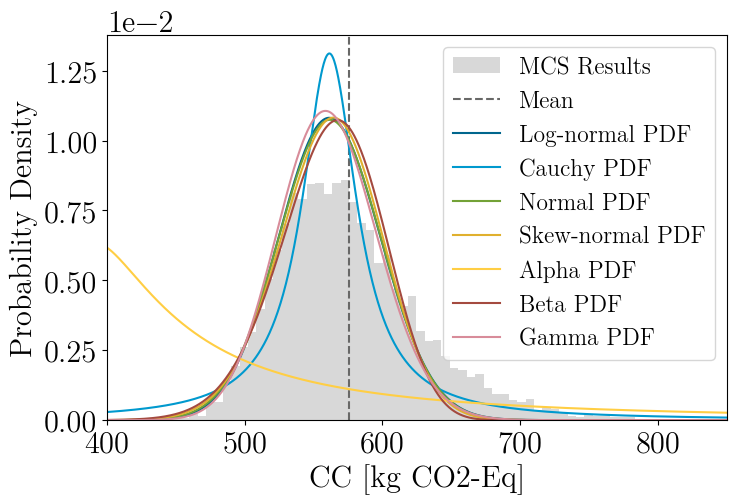

In [4]:

### impact category 'climate change no LT [kg CO2-Eq]'

plt.figure(figsize=(8, 5))

plotting_data = demand['mc_results']['climate change no LT [kg CO2-Eq]']

# plot the histogram of the data
plt.hist(plotting_data, bins='auto', color=light_gray, label='MCS Results', density=True, alpha=0.5)

# show the mean and mean +- standard deviation
plt.axvline(demand['mc_statistics']['climate change no LT [kg CO2-Eq]']['mean'], color=gray, linestyle='--', label='Mean')

colors = [blue, light_blue, green, yellow, light_yellow, red, pink]
labels = ['Log-normal PDF', 'Cauchy PDF', 'Normal PDF', 'Skew-normal PDF', 'Alpha PDF', 'Beta PDF', 'Gamma PDF']


# plot all the fitted distributions in the colors defined above
for result in demand['distribution_results']['climate change no LT [kg CO2-Eq]']:
    distribution = getattr(stats, result['distribution'])
    x = np.linspace(min(plotting_data), max(plotting_data), len(plotting_data))
    pdf_values = distribution.pdf(x, *result['params'][:-2], loc=result['params'][-2], scale=result['params'][-1])
    plt.plot(x, pdf_values, label=labels.pop(0), color=colors.pop(0))
    
plt.xlim(400, 850)

# set axis labels
plt.xlabel('CC [kg CO2-Eq]')
plt.ylabel('Probability Density')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# place the legend outside the plot, right of it
# plt.legend(loc='lower right', bbox_to_anchor=(1, 1), ncol=3)
plt.legend(fontsize=17)


plt.savefig('mcs_a_check_cc.png', dpi=900, bbox_inches='tight')
plt.show()

In [ ]:
### impact category 'acidification no LT [mol H+-Eq]'

plt.figure(figsize=(8, 5))

plotting_data = demand['mc_results']['acidification no LT [mol H+-Eq]']

# plot the histogram of the data
plt.hist(plotting_data, bins='auto', color=light_gray, label='MCS Results', density=True, alpha=0.5)

# show the mean and mean +- standard deviation
plt.axvline(demand['mc_statistics']['acidification no LT [mol H+-Eq]']['mean'], color=gray, linestyle='--', label='Mean')

colors = [blue, light_blue, green, yellow, light_yellow, red, pink]
labels = ['Log-normal PDF', 'Cauchy PDF', 'Normal PDF', 'Skew-normal PDF', 'Alpha PDF', 'Beta PDF', 'Gamma PDF']

# plot all the fitted distributions in the colors defined above
for result in demand['distribution_results']['acidification no LT [mol H+-Eq]']:
    distribution = getattr(stats, result['distribution'])
    x = np.linspace(min(plotting_data), max(plotting_data), len(plotting_data))
    pdf_values = distribution.pdf(x, *result['params'][:-2], loc=result['params'][-2], scale=result['params'][-1])
    plt.plot(x, pdf_values, label=labels.pop(0), color=colors.pop(0))
    
plt.xlim(2, 3.7)

# set axis labels
plt.xlabel('ADP [mol H+-Eq]')
plt.ylabel('Probability Density')

# place the legend outside the plot, right of it
# plt.legend(loc='lower right', bbox_to_anchor=(1, 1), ncol=3)
plt.legend()

plt.savefig('mcs_a_check_adp.png', dpi=900, bbox_inches='tight')
plt.show()

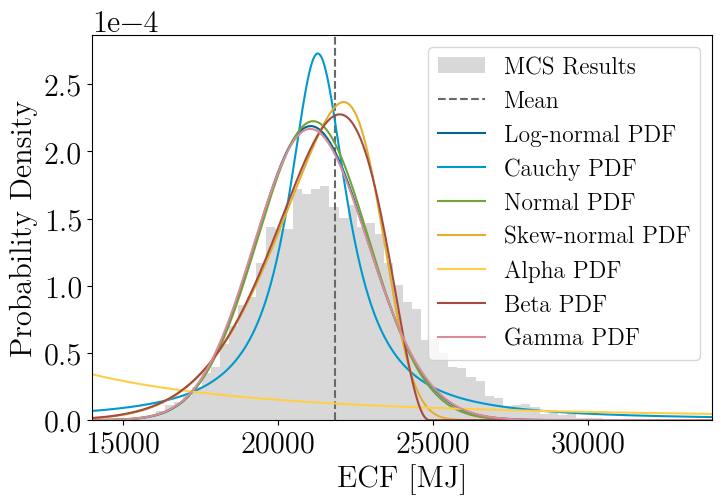

In [5]:
### impact category 'energy resources: non-renewable no LT [MJ, net calorific value]'

plt.figure(figsize=(8, 5))

plotting_data = demand['mc_results']['energy resources: non-renewable no LT [MJ, net calorific value]']

# plot the histogram of the data
plt.hist(plotting_data, bins='auto', color=light_gray, label='MCS Results', density=True, alpha=0.5)

# show the mean and mean +- standard deviation
plt.axvline(demand['mc_statistics']['energy resources: non-renewable no LT [MJ, net calorific value]']['mean'], color=gray, linestyle='--', label='Mean')

colors = [blue, light_blue, green, yellow, light_yellow, red, pink]
labels = ['Log-normal PDF', 'Cauchy PDF', 'Normal PDF', 'Skew-normal PDF', 'Alpha PDF', 'Beta PDF', 'Gamma PDF']

# plot all the fitted distributions in the colors defined above
for result in demand['distribution_results']['energy resources: non-renewable no LT [MJ, net calorific value]']:
    distribution = getattr(stats, result['distribution'])
    x = np.linspace(min(plotting_data), max(plotting_data), len(plotting_data))
    pdf_values = distribution.pdf(x, *result['params'][:-2], loc=result['params'][-2], scale=result['params'][-1])
    plt.plot(x, pdf_values, label=labels.pop(0), color=colors.pop(0))
    
plt.xlim(14000, 34000)

# set axis labels
plt.xlabel('ECF [MJ]')
plt.ylabel('Probability Density')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# place the legend outside the plot, right of it
# plt.legend(loc='lower right', bbox_to_anchor=(1, 1), ncol=3)
plt.legend(fontsize=17)

plt.savefig('mcs_a_check_ecf.png', dpi=900, bbox_inches='tight')
plt.show()

Import MCS data for all cradle-to-gate LCAs

In [ ]:
# import json data for cradle-to-gate LCA results
      
input_file_list = [file for file in os.listdir(r"C:\Git_LYFE\airlyfe\productive_results") if file.startswith("lca_") and file.endswith("_monte_carlo.json")]
input_file_list.sort(key=lambda x: int(x.split('_')[1]))

overview_data = pd.read_excel(r"G:\Studenten\PLM\MariaHoeller\Overview_Individual_LCAs.xlsx")

# get the mean and standard deviation of each demand
name_list = []
name_list_short = []
mean_list = []
std_list = []
mcs_results = []
qmin_list = []
qmax_list = []

for file in input_file_list:
    with open(os.path.join(r"C:\Git_LYFE\airlyfe\productive_results", file), 'r') as file:  
        demand = json.load(file)
        
        name_plots = overview_data.loc[overview_data['Demand name'].str.lower() == demand['name'].lower(), 'Name for Plots'].values[0]
        name_list.append(name_plots)
        name_list_short.append(overview_data.loc[overview_data['Demand name'].str.lower() == demand['name'].lower(), 'Name for Plots (Short)'].values[0])
        mean_list.append(demand['mc_statistics']['climate change no LT [kg CO2-Eq]']['mean'])
        std_list.append(demand['mc_statistics']['climate change no LT [kg CO2-Eq]']['std'])
        mcs_results.append(demand['mc_results']['climate change no LT [kg CO2-Eq]'])
        qmin_list.append(demand['mc_statistics']['climate change no LT [kg CO2-Eq]']['percentiles']['10'])
        qmax_list.append(demand['mc_statistics']['climate change no LT [kg CO2-Eq]']['percentiles']['90'])
        
    if demand['name'] == 'market for electricity, medium voltage':
        break
        
for name, mean, std in zip(name_list_short, mean_list, std_list):
    print(f"{name}: {mean + std}")
    
print(mcs_results)

In [ ]:
# minimum = {
#     'Aircraft Production': 0,
#     'Air Freight': 0,
#     'Very Short Haul Flight': 0,
#     'Short Haul Flight': 0,
#     'Medium Haul Flight': 0,
#     'Long Haul Flight': 0,
#     'Kerosene Production': 0,
#     'A-Check': 0,
#     'APU Shop Visit': 0,
#     'C-Check': 0,
#     'D-Check': 0,
#     'Daily Check': 0,
#     'Full Overhaul': 0,
#     'Hot Section Inspection': 0,
#     'Exc. of Compressor': 0,
#     'Exc. of Fan': 0,
#     'Exc. of HPT': 0,
#     'Exc. of LPT': 0,
#     'Landing Gear Shop': 0,
#     'Pre-Flight Check': 0,
#     'Aircraft Transport': 0,
#     'Weekly Check': 0,
#     'Electricity Production': 0      
# }

# maximum = {
#     'Aircraft Production': 3348220,
#     'Air Freight': 0.8788,
#     'Very Short Haul Flight': 0.20,
#     'Short Haul Flight': 0.15,
#     'Medium Haul Flight': 0.154,
#     'Long Haul Flight': 0.119,
#     'Kerosene Production': 1.46,
#     'A-Check': 636,
#     'APU Shop Visit': 53695,
#     'C-Check': 29846,
#     'D-Check': 165094,
#     'Daily Check': 79.6,
#     'Full Overhaul': 21408,
#     'Hot Section Inspection': 18303,
#     'Exc. of Compressor': 441394,
#     'Exc. of Fan': 21402,
#     'Exc. of HPT': 454597,
#     'Exc. of LPT': 66408,
#     'Landing Gear Shop': 44676,
#     'Pre-Flight Check': 0.9,
#     'Aircraft Transport': 2.43,
#     'Weekly Check': 113,
#     'Electricity Production': 0.54      
# }


minimum = {}
maximum = {}
for name, mean, std, qmin, qmax in zip(name_list_short, mean_list, std_list, qmin_list, qmax_list):
    minimum[name] = qmin - 0.1 * np.random.random() * qmin
    maximum[name] = qmax + 0.1 * np.random.random() * qmax

In [ ]:
plt.figure(figsize=(12, 5))

positions_mc = [i - 0.2 for i in range(len(name_list))]

# Create the half violin plot
plotting_data = []
for (result, mean, name) in zip(mcs_results, mean_list, name_list_short):
    if 'Pre-Flight Check' in name:
        result = mcs_results[1]
        mean = mean_list[1]
        
    plotting_data.append([abs(value/mean *100) if mean != 0 else value for value in result])

# plotting_data = [[abs(value/mean *100) if mean != 0 else value for value in result] for (result, mean) in zip(mcs_results, mean_list)]

# filter out outliers in plotting_data (any datapoint that is more than 3stds away from its mean)
plotting_data = [np.array(result)[(np.array(result) >= 0) & (np.array(result) <= (np.array(result).mean() + 2*np.array(result).std()))] for result in plotting_data]

parts = plt.violinplot(plotting_data, positions_mc, showextrema=False, points=1000)

for i, pc in enumerate(parts['bodies']):
    path = pc.get_paths()[0]
    vertices = path.vertices
    
    # Only keep the left half
    vertices[:, 0] = np.clip(vertices[:, 0], -np.inf, np.median(vertices[:, 0]))
    pc.set_verts([vertices])
    pc.set_facecolor(light_blue)
    
# settings for the box plot
flierprops = dict(marker='o', markerfacecolor=light_blue, markersize=3, markeredgecolor='none')
whiskerprops = dict(color=light_blue)
boxprops = dict(color=light_blue)
medianprops = dict(color=light_blue)
capsprops = dict(color=light_blue)

plt.boxplot(plotting_data, positions=positions_mc, widths=0.19, whis=[5, 95], notch=False, flierprops=flierprops, boxprops=boxprops, medianprops=medianprops, whiskerprops=whiskerprops, capprops=capsprops, showfliers=False)

# plot min-mean-max data
for i, (demand, mean) in enumerate(zip(name_list_short, mean_list)):
    min = minimum[demand] / mean * 100 if mean != 0 else minimum[demand]
    max = maximum[demand] / mean * 100 if mean * 100 != 0 else maximum[demand]
    
    if min < 0:
        min = 0 
        
    if 'Pre-Flight Check' in demand:
        min = minimum['Air Freight'] / mean_list[1] * 100
        max = maximum['Air Freight'] / mean_list[1] * 100
    
    plt.plot([i + 0.1, i + 0.1], [min, max], color=light_green, zorder=1)
    plt.scatter(i + 0.1, min, color=light_green, marker='_', zorder=1)
    plt.scatter(i + 0.1, max, color=light_green, marker='_', zorder=1)
    
    # plot deterministic result
    # plt.scatter(i, 100, color=gray, marker='o', zorder=2)
    
# manually add Monte Carlo legend entry
line_mc = Line2D([0], [0], color=light_blue, label='Monte Carlo Simulation')
line_mmm = Line2D([0], [0], color=light_green, label='Min-Mean-Max Propagation')

# add labels and legend
plt.ylabel('Normalized CC Scores [%]')
plt.legend(handles=[line_mc, line_mmm], loc='upper left')
plt.ylim(0,200)

plt.xticks(range(len(mcs_results)), labels=name_list_short, rotation=90, va='top')

plt.savefig('propagation-comparison.png', dpi=900, bbox_inches='tight')
    
plt.show()

In [ ]:
def plotting_propagation(selection):
    plt.figure(figsize=(10, 6))

    positions_mc = [i - 0.2 for i in range(len(selection))]

    # Create the half violin plot
    plotting_data = []
    for result, mean, name in zip(mcs_results, mean_list, name_list_short):
        if name in selection:
            plotting_data.append([value/mean *100 if mean != 0 else value for value in result])
    parts = plt.violinplot(plotting_data, positions_mc, showextrema=False)

    for i, pc in enumerate(parts['bodies']):
        path = pc.get_paths()[0]
        vertices = path.vertices
        
        # Only keep the left half
        vertices[:, 0] = np.clip(vertices[:, 0], -np.inf, np.median(vertices[:, 0]))
        pc.set_verts([vertices])
        pc.set_facecolor(light_blue)
        
    # settings for the box plot
    flierprops = dict(marker='o', markerfacecolor=light_blue, markersize=3, markeredgecolor='none')
    whiskerprops = dict(color=light_blue)
    boxprops = dict(color=light_blue)
    medianprops = dict(color=light_blue)
    capsprops = dict(color=light_blue)

    # plot min-mean-max data
    for i, demand in enumerate(selection):
        min = minimum[demand]
        max = maximum[demand]
        
        plt.plot([i - 0.1, i - 0.1], [min, max], color=light_green, zorder=1)
        plt.scatter(i - 0.1, min, color=light_green, marker='_', zorder=1)
        plt.scatter(i - 0.1, max, color=light_green, marker='_', zorder=1)
        
        # plot deterministic result
        # plt.scatter(i, 100, color=gray, marker='o', zorder=2)
        
    # manually add Monte Carlo legend entry
    line_mc = Line2D([0], [0], color=light_blue, label='Monte Carlo')
    line_mmm = Line2D([0], [0], color=light_green, label='Min-Max')

    # add labels and legend
    plt.ylabel('Normalized Global Warming Potential Score [%]')
    plt.legend(handles=[line_mc, line_mmm], loc='upper right')
    # plt.ylim(-100,400)

    plt.xticks(range(len(selection)), labels=selection, rotation=90, va='top')
        
    plt.show()
    
selection_production = ['Aircraft Production', 'Air Freight', 'Kerosene Production']
selection_flight_ops = ['Very Short Haul Flight', 'Short Haul Flight', 'Medium Haul Flight', 'Long Haul Flight']
selection_maintenance = ['A-Check', 'APU Shop Visit', 'C-Check', 'D-Check', 'Daily Check', 'Full Overhaul', 'Hot Section Inspection', 'Exc. of Compressor', 'Exc. of Fan', 'Exc. of HPT', 'Exc. of LPT', 'Landing Gear Shop', 'Pre-Flight Check', 'Aircraft Transport', 'Weekly Check']

plotting_propagation(selection_production)
plotting_propagation(selection_flight_ops)
plotting_propagation(selection_maintenance)
